# Week 3 - Customer Intelligence System
**Name:** Ghanist Agrawal  
**Dataset:** Unsupervised Learning on Country Data (Kaggle)  
**Objective:** Build a Customer Intelligence System using K-Means, DBSCAN clustering and classification with Random Forest + XGBoost ensemble models

In [111]:
!pip install xgboost --quiet

In [112]:
# importing everything needed for this notebook
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing and model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA

# clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

# classification and ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import joblib

SEED = 42
sns.set_theme(style='whitegrid')
print('setup done')

setup done


## 1. Load Dataset

In [114]:
data = pd.read_csv('Country-data.csv')
print('rows x columns:', data.shape)
data.head()

rows x columns: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [116]:
data.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 2. Data Cleaning
checking quality before doing anything else

In [118]:
print('null values per column:')
print(data.isnull().sum())
print('\nduplicate rows:', data.duplicated().sum())

null values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

duplicate rows: 0


In [119]:
# keeping country names for labeling results later
# dropping country from features since its just a name, not a number
country_list = data['country'].values
features_df  = data.drop(columns=['country'])

print('feature columns:', features_df.columns.tolist())
print('total countries:', len(country_list))

feature columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
total countries: 167


In [120]:
# StandardScaler is essential here
# gdpp ranges in thousands, health ranges 0-20 - without scaling gdpp dominates distance calculations
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

scaled_df = pd.DataFrame(X_scaled, columns=features_df.columns)
print('after scaling - mean should be ~0 and std ~1:')
print(scaled_df.describe().loc[['mean', 'std']].round(2))

after scaling - mean should be ~0 and std ~1:
      child_mort  exports  health  imports  income  inflation  life_expec  \
mean        -0.0      0.0     0.0      0.0    -0.0       -0.0         0.0   
std          1.0      1.0     1.0      1.0     1.0        1.0         1.0   

      total_fer  gdpp  
mean        0.0   0.0  
std         1.0   1.0  


## 3. EDA - Exploratory Data Analysis

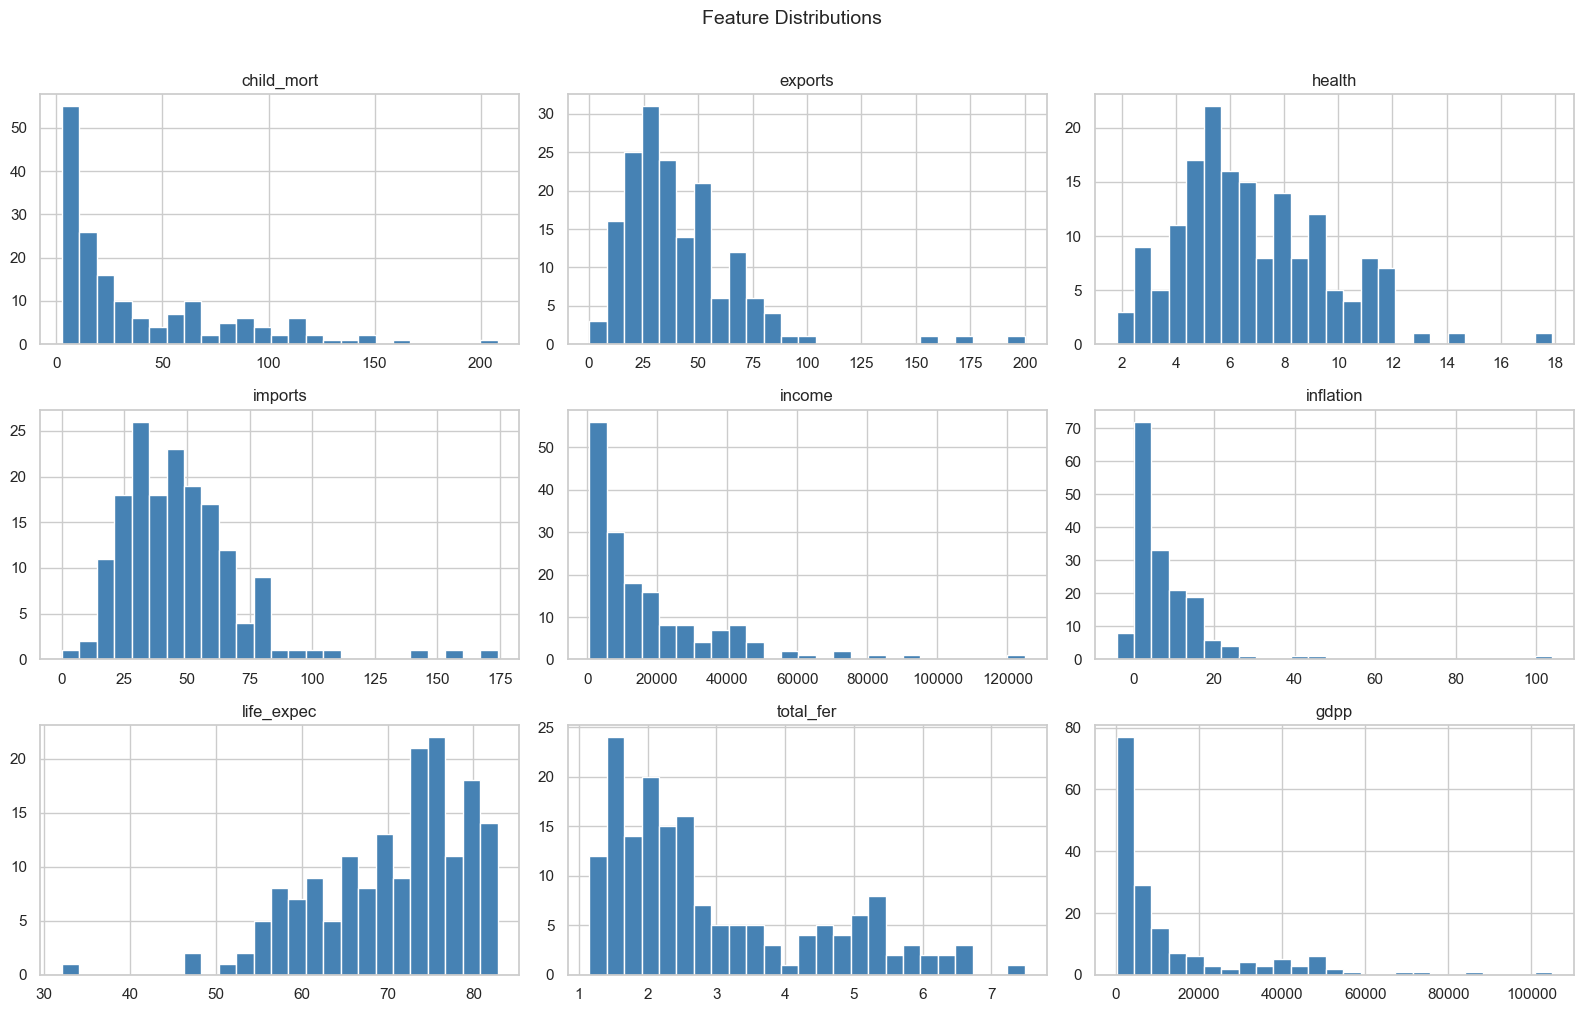

In [122]:
# distributions of all features before modeling
features_df.hist(figsize=(16, 10), bins=25, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

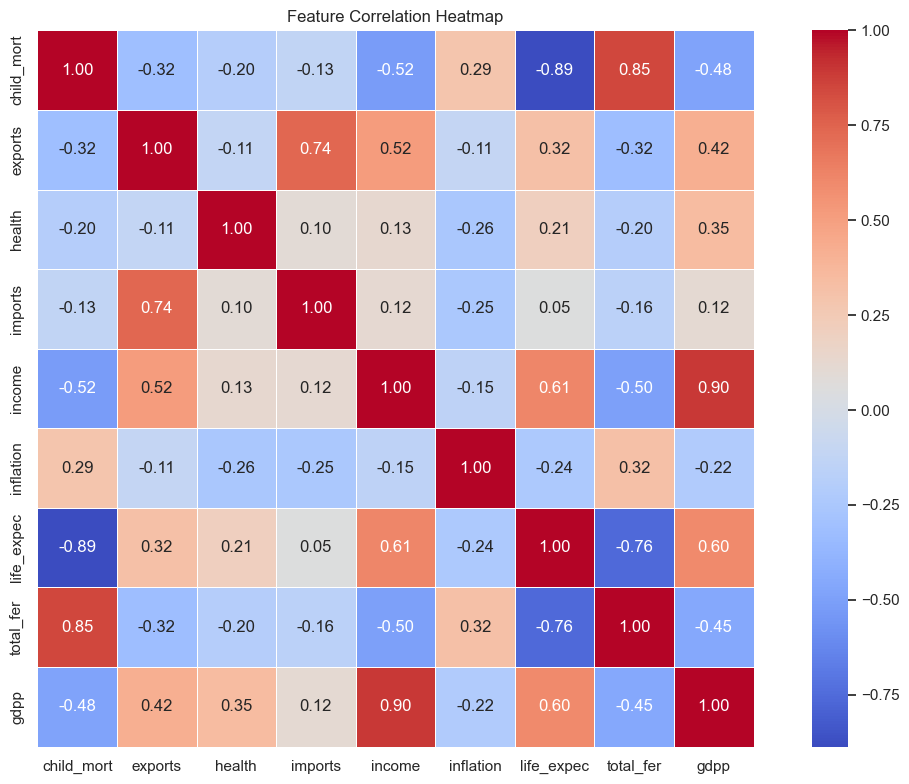

In [123]:
# correlation heatmap - checking which features are related
plt.figure(figsize=(12, 8))
corr_matrix = features_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

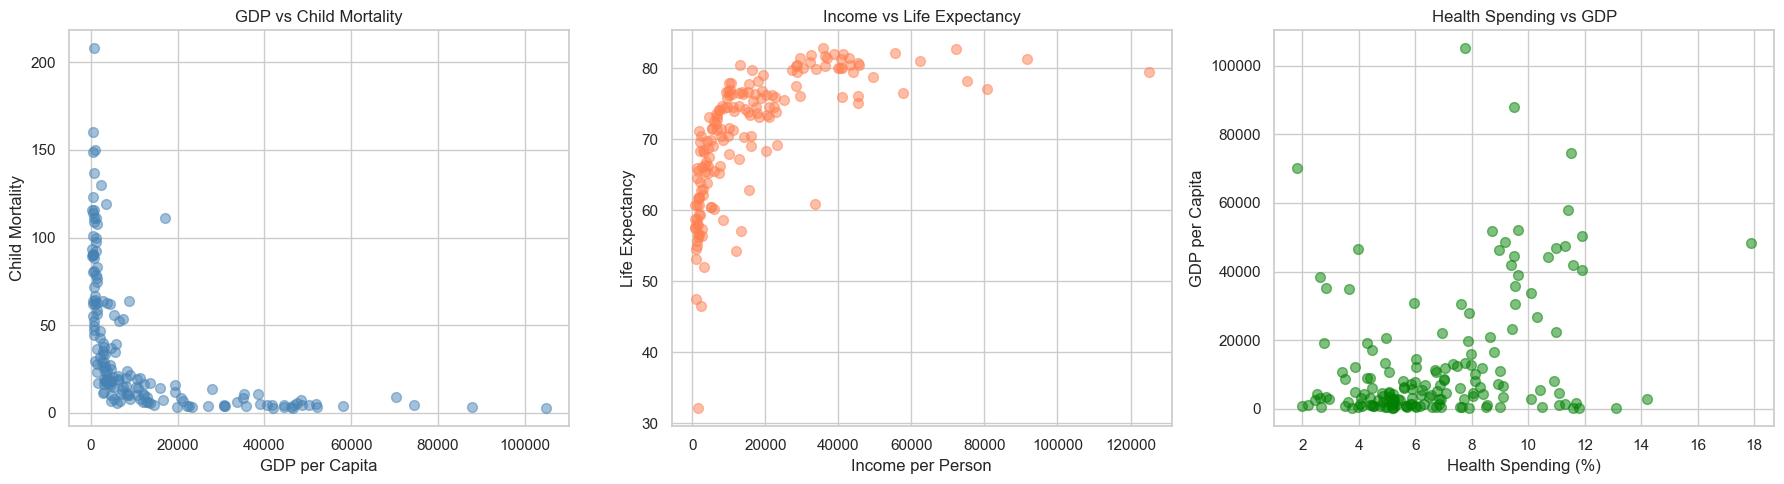

In [124]:
# key scatter plots - economic development tells a strong story here
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(features_df['gdpp'], features_df['child_mort'],
                alpha=0.5, color='steelblue', s=50)
axes[0].set_xlabel('GDP per Capita')
axes[0].set_ylabel('Child Mortality')
axes[0].set_title('GDP vs Child Mortality')

axes[1].scatter(features_df['income'], features_df['life_expec'],
                alpha=0.5, color='coral', s=50)
axes[1].set_xlabel('Income per Person')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Income vs Life Expectancy')

axes[2].scatter(features_df['health'], features_df['gdpp'],
                alpha=0.5, color='green', s=50)
axes[2].set_xlabel('Health Spending (%)')
axes[2].set_ylabel('GDP per Capita')
axes[2].set_title('Health Spending vs GDP')

plt.tight_layout()
plt.show()

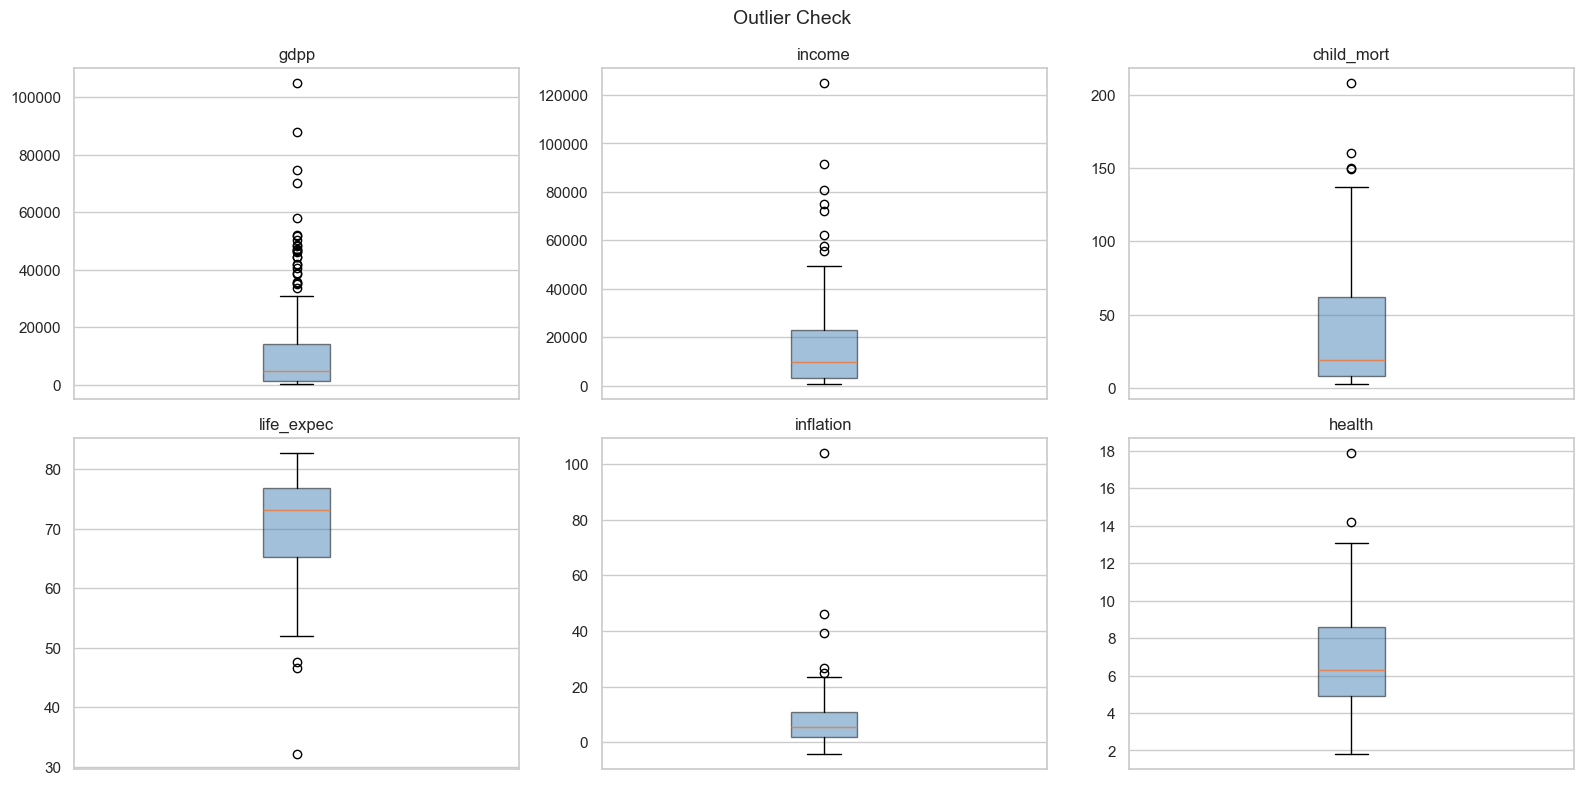

In [125]:
# boxplots to spot outliers before clustering
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_check = ['gdpp', 'income', 'child_mort', 'life_expec', 'inflation', 'health']

for ax, col in zip(axes.flatten(), cols_to_check):
    ax.boxplot(features_df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Outlier Check', fontsize=14)
plt.tight_layout()
plt.show()

## 4. PCA - Reducing to 2D for Visualization
not using this for actual modeling - just so we can plot the clusters

In [127]:
pca_2d = PCA(n_components=2, random_state=SEED)
coords_2d = pca_2d.fit_transform(X_scaled)

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

print(f'PC1 captures {var1:.1f}% of variance')
print(f'PC2 captures {var2:.1f}% of variance')
print(f'Total: {var1+var2:.1f}%')

PC1 captures 46.0% of variance
PC2 captures 17.2% of variance
Total: 63.1%


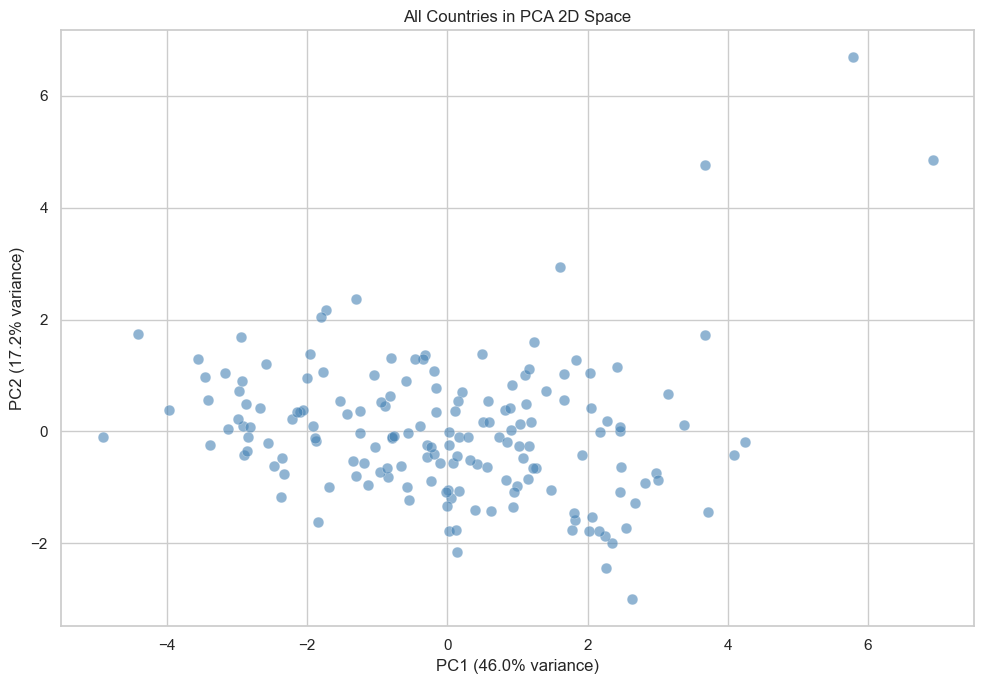

In [128]:
plt.figure(figsize=(10, 7))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1],
            alpha=0.6, s=60, color='steelblue', edgecolors='white', linewidth=0.3)
plt.title('All Countries in PCA 2D Space')
plt.xlabel(f'PC1 ({var1:.1f}% variance)')
plt.ylabel(f'PC2 ({var2:.1f}% variance)')
plt.tight_layout()
plt.show()

## 5. K-Means Clustering
finding how many clusters to use with elbow + silhouette score

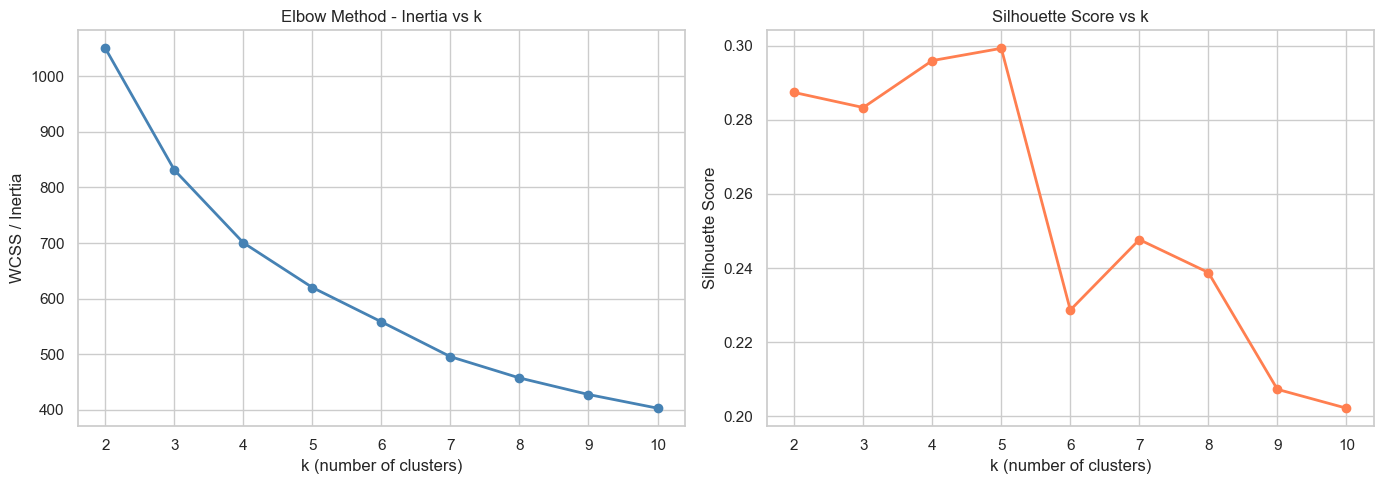

best k based on silhouette: 5


In [130]:
wcss_vals  = []
sil_vals   = []
k_values   = range(2, 11)

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km_temp.fit(X_scaled)
    wcss_vals.append(km_temp.inertia_)
    sil_vals.append(silhouette_score(X_scaled, km_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, wcss_vals, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method - Inertia vs k')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('WCSS / Inertia')

axes[1].plot(k_values, sil_vals, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_values)[sil_vals.index(max(sil_vals))]
print(f'best k based on silhouette: {best_k}')

In [131]:
# training the final kmeans model with the chosen k
kmeans_model  = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_ids   = kmeans_model.fit_predict(X_scaled)

unique_clusters, cluster_sizes = np.unique(cluster_ids, return_counts=True)
print(f'KMeans trained with k={best_k}')
for c, s in zip(unique_clusters, cluster_sizes):
    print(f'  cluster {c}: {s} countries')

KMeans trained with k=5
  cluster 0: 84 countries
  cluster 1: 47 countries
  cluster 2: 3 countries
  cluster 3: 32 countries
  cluster 4: 1 countries


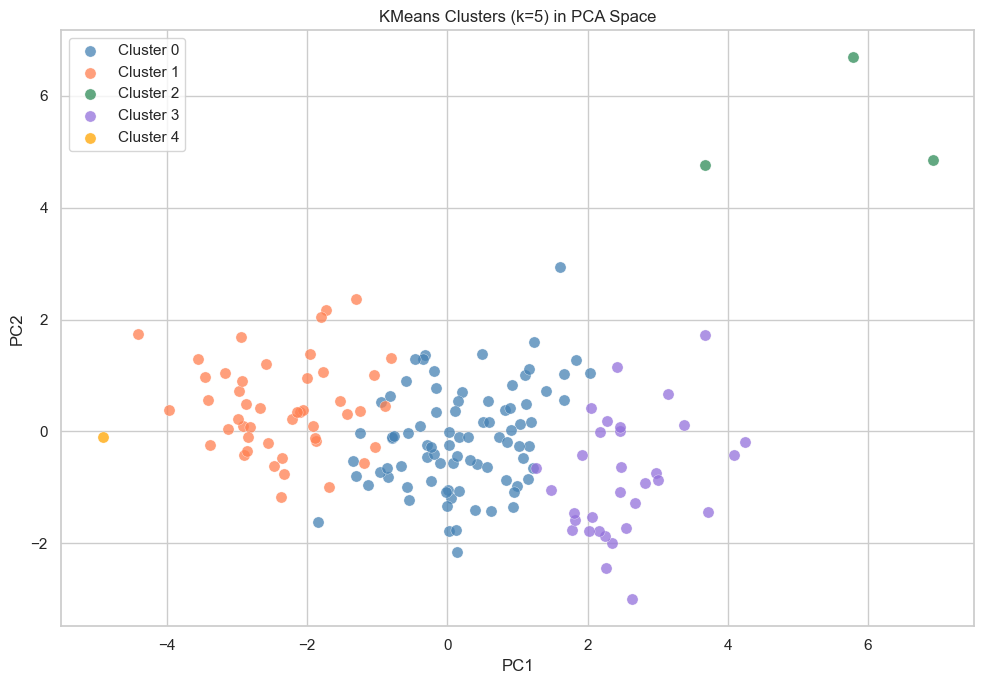

In [132]:
# visualizing the clusters using our 2D PCA coordinates
palette  = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'orange']

plt.figure(figsize=(10, 7))
for i in range(best_k):
    mask = cluster_ids == i
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                label=f'Cluster {i}',
                color=palette[i % len(palette)],
                alpha=0.75, s=65, edgecolors='white', linewidth=0.3)

plt.title(f'KMeans Clusters (k={best_k}) in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
# cluster profiling - what does each cluster actually look like?
profile_df = features_df.copy()
profile_df['cluster']  = cluster_ids
profile_df['country']  = country_list

cluster_means = profile_df.groupby('cluster')[features_df.columns].mean().round(2)
print('mean values per cluster:')
print(cluster_means)

mean values per cluster:
         child_mort  exports  health  imports    income  inflation  \
cluster                                                              
0             21.61    40.98    6.17    47.52  12801.07       7.62   
1             90.79    29.66    6.46    43.68   3870.70       9.95   
2              4.13   176.00    6.79   156.67  64033.33       2.47   
3              5.18    46.12    9.09    40.58  44021.88       2.51   
4            130.00    25.30    5.07    17.40   5150.00     104.00   

         life_expec  total_fer      gdpp  
cluster                                   
0             73.00       2.28   6581.81  
1             59.21       4.97   1900.26  
2             81.43       1.38  57566.67  
3             80.08       1.79  42118.75  
4             60.50       5.84   2330.00  


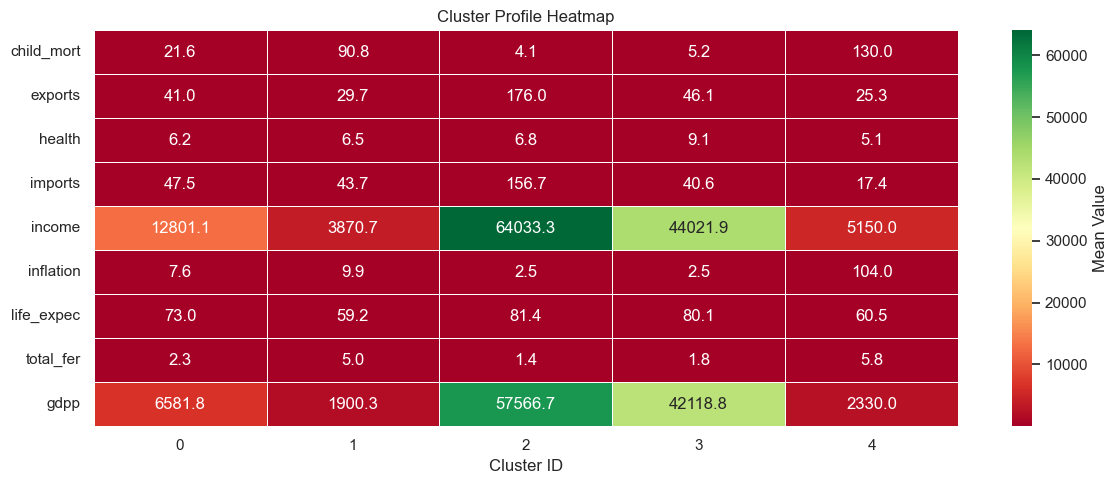

In [134]:
# heatmap makes the profile much easier to read than raw numbers
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_means.T, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.4,
            cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profile Heatmap')
plt.xlabel('Cluster ID')
plt.tight_layout()
plt.show()

In [135]:
# assigning meaningful names based on gdpp and child mortality
# cluster with highest gdpp = developed, lowest = underdeveloped
gdpp_rank     = cluster_means['gdpp'].rank(ascending=False)
segment_names = {}
for cid in cluster_means.index:
    rank = gdpp_rank[cid]
    if rank == 1:
        segment_names[cid] = 'Developed'
    elif rank == best_k:
        segment_names[cid] = 'Underdeveloped'
    else:
        segment_names[cid] = 'Developing'

profile_df['segment'] = profile_df['cluster'].map(segment_names)

print('cluster to segment mapping:')
for k, v in segment_names.items():
    print(f'  Cluster {k} → {v}')

cluster to segment mapping:
  Cluster 0 → Developing
  Cluster 1 → Underdeveloped
  Cluster 2 → Developed
  Cluster 3 → Developing
  Cluster 4 → Developing


In [136]:
# kmeans evaluation metrics
km_sil = silhouette_score(X_scaled, cluster_ids)
km_dbi = davies_bouldin_score(X_scaled, cluster_ids)

print(f'Silhouette Score  : {km_sil:.4f}  (higher = better, max 1.0)')
print(f'Davies-Bouldin    : {km_dbi:.4f}  (lower  = better)')

Silhouette Score  : 0.2993  (higher = better, max 1.0)
Davies-Bouldin    : 0.8718  (lower  = better)


**KMeans observation:** The three clusters map clearly to economic development levels. GDP per capita and child mortality are the two most separating features — countries with high GDP consistently show low child mortality and high life expectancy.

## 6. DBSCAN Clustering
density-based approach - finds outlier countries that dont fit any cluster

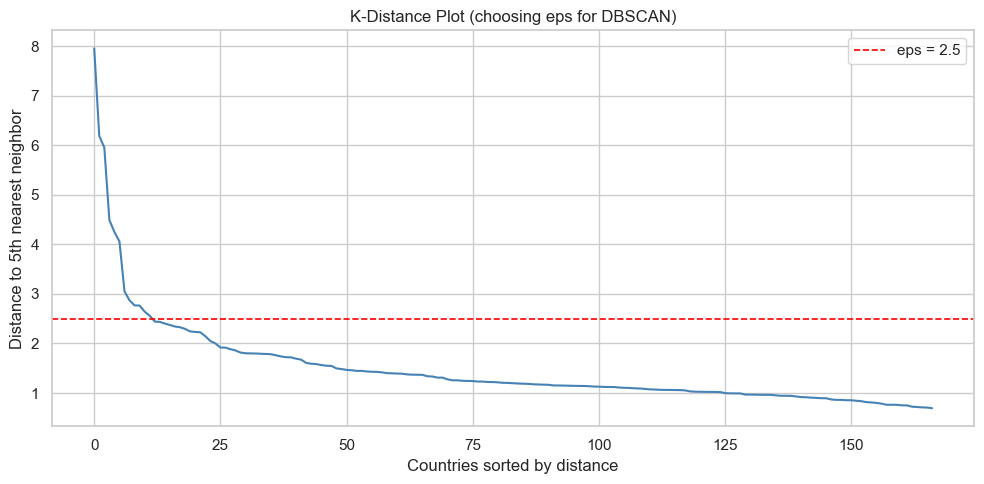

In [139]:
# using k-distance plot to pick eps - the elbow point is where we set eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dist_matrix, _ = nbrs.kneighbors(X_scaled)
knn_distances   = np.sort(dist_matrix[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(knn_distances, color='steelblue', linewidth=1.5)
plt.axhline(y=2.5, color='red', linestyle='--', linewidth=1.2, label='eps = 2.5')
plt.title('K-Distance Plot (choosing eps for DBSCAN)')
plt.xlabel('Countries sorted by distance')
plt.ylabel('Distance to 5th nearest neighbor')
plt.legend()
plt.tight_layout()
plt.show()

In [140]:
# running DBSCAN - label -1 means the country is an outlier
db_model    = DBSCAN(eps=2.5, min_samples=5)
db_labels   = db_model.fit_predict(X_scaled)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers    = (db_labels == -1).sum()

print(f'clusters found : {n_db_clusters}')
print(f'outlier points : {n_outliers}')

vals, cnts = np.unique(db_labels, return_counts=True)
print('label counts   :', dict(zip(vals, cnts)))

clusters found : 1
outlier points : 6
label counts   : {-1: 6, 0: 161}


In [141]:
# showing which countries were marked as outliers
if n_outliers > 0:
    outlier_countries = country_list[db_labels == -1]
    print(f'outlier countries ({n_outliers} total):')
    print(', '.join(outlier_countries))

outlier countries (6 total):
Haiti, Luxembourg, Malta, Nigeria, Qatar, Singapore


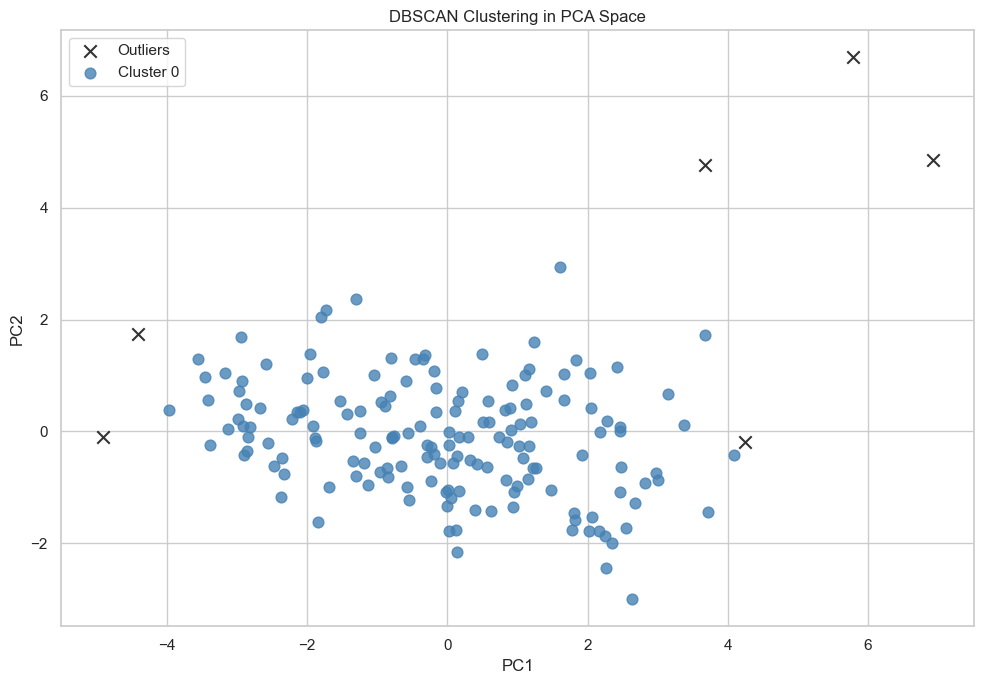

In [142]:
# visualizing DBSCAN - black X marks are the outliers
plt.figure(figsize=(10, 7))
db_color_map = {-1: 'black', 0: 'steelblue', 1: 'coral', 2: 'seagreen', 3: 'mediumpurple'}

for lbl in sorted(set(db_labels)):
    mask    = db_labels == lbl
    label_name = 'Outliers' if lbl == -1 else f'Cluster {lbl}'
    mkr     = 'x' if lbl == -1 else 'o'
    sz      = 80 if lbl == -1 else 60
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                c=db_color_map.get(lbl, 'gray'),
                marker=mkr, s=sz, alpha=0.8,
                label=label_name)

plt.title('DBSCAN Clustering in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
# dbscan metrics - only calculate if we got more than 1 cluster
if n_db_clusters > 1:
    valid_mask  = db_labels != -1
    db_sil  = silhouette_score(X_scaled[valid_mask], db_labels[valid_mask])
    db_dbi  = davies_bouldin_score(X_scaled[valid_mask], db_labels[valid_mask])
    print(f'DBSCAN Silhouette  : {db_sil:.4f}')
    print(f'DBSCAN DBI         : {db_dbi:.4f}')
else:
    db_sil = 0
    db_dbi = 0
    print('DBSCAN found only 1 cluster - eps may need adjusting')

DBSCAN found only 1 cluster - eps may need adjusting


In [144]:
# side by side comparison of both clustering methods
print('=' * 55)
print(f'{"Method":<12} {"Clusters":<12} {"Silhouette":<15} {"DBI"}')
print('-' * 55)
print(f'{"KMeans":<12} {best_k:<12} {km_sil:<15.4f} {km_dbi:.4f}')
if n_db_clusters > 1:
    print(f'{"DBSCAN":<12} {n_db_clusters:<12} {db_sil:<15.4f} {db_dbi:.4f}')
print('=' * 55)

Method       Clusters     Silhouette      DBI
-------------------------------------------------------
KMeans       5            0.2993          0.8718


**DBSCAN observation:** DBSCAN identifies extreme outlier countries - typically very small nations or countries with unusual economic profiles (like oil-rich countries with high GDP but other poor indicators). These are hard to classify and KMeans forces them into a cluster even when they don't belong.

## 7. Setting Up Classification
using kmeans cluster labels as the target - now we train classifiers to predict which segment a country belongs to

In [147]:
X_clf = X_scaled.copy()
y_clf = cluster_ids.copy()

# checking cluster sizes before deciding stratification strategy
class_counts = pd.Series(y_clf).value_counts()
print('samples per class:')
print(class_counts)

# only stratify if every class has at least 2 samples (otherwise train_test_split crashes)
use_strat = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=SEED,
    stratify=y_clf if use_strat else None
)

print(f'\ntrain: {X_train.shape[0]} samples')
print(f'test : {X_test.shape[0]} samples')
print('used stratified split:', use_strat)

samples per class:
0    84
1    47
3    32
2     3
4     1
Name: count, dtype: int64

train: 133 samples
test : 34 samples
used stratified split: False


## 8. Baseline - Logistic Regression
starting simple to have something to compare against

In [149]:
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train, y_train)
lr_preds = log_reg.predict(X_test)

print('=== Logistic Regression (Baseline) ===')
print(f'test accuracy: {accuracy_score(y_test, lr_preds):.4f}')
print()
print(classification_report(y_test, lr_preds))

=== Logistic Regression (Baseline) ===
test accuracy: 0.9706

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.97        34
   macro avg       0.97      0.99      0.98        34
weighted avg       0.97      0.97      0.97        34



## 9. Ensemble - Random Forest
builds many decision trees independently and averages their votes

In [151]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)

print('=== Random Forest ===')
print(f'test accuracy: {accuracy_score(y_test, rf_preds):.4f}')
print()
print(classification_report(y_test, rf_preds))

=== Random Forest ===
test accuracy: 0.9412

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.94        34
   macro avg       0.70      0.75      0.72        34
weighted avg       0.89      0.94      0.91        34



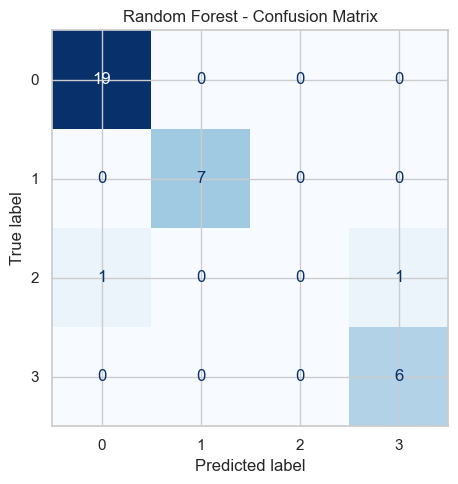

In [152]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax, colorbar=False,
                                        cmap='Blues')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Ensemble - XGBoost
gradient boosting - each tree fixes the errors of the one before it

In [154]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=SEED,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
xgb_preds = xgb_clf.predict(X_test)

print('=== XGBoost ===')
print(f'test accuracy: {accuracy_score(y_test, xgb_preds):.4f}')
print()
print(classification_report(y_test, xgb_preds))

=== XGBoost ===
test accuracy: 0.8824

              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.86      0.86      0.86         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.88        34
   macro avg       0.65      0.70      0.68        34
weighted avg       0.83      0.88      0.86        34



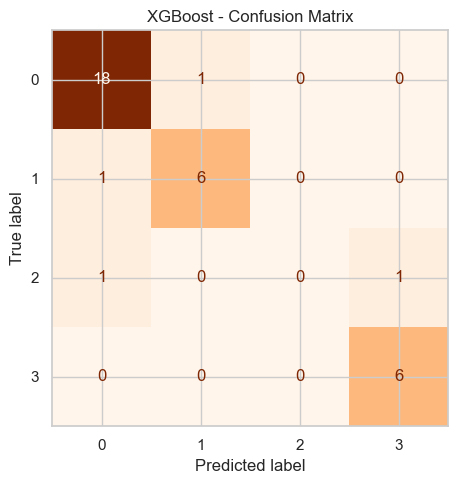

In [155]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds, ax=ax, colorbar=False,
                                        cmap='Oranges')
ax.set_title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning - Random Forest

In [157]:
rf_grid_params = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features'    : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_grid_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print('best RF parameters :', rf_grid.best_params_)
print('best CV accuracy   :', round(rf_grid.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
# saving best RF for comparison later
best_rf = rf_grid.best_estimator_
best_rf_preds = best_rf.predict(X_test)
print(f'RF Tuned test accuracy: {accuracy_score(y_test, best_rf_preds):.4f}')

## 12. Hyperparameter Tuning - XGBoost

In [ ]:
xgb_grid_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='mlogloss'),
    xgb_grid_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

print('best XGBoost parameters :', xgb_grid.best_params_)
print('best CV accuracy        :', round(xgb_grid.best_score_, 4))

In [ ]:
# saving best XGBoost for comparison
best_xgb = xgb_grid.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)
print(f'XGBoost Tuned test accuracy: {accuracy_score(y_test, best_xgb_preds):.4f}')

## 13. Final Model Comparison
all 5 models head to head

In [ ]:
def score_model(name, model, Xtr, ytr, Xte, yte):
    ypred  = model.predict(Xte)
    cv_acc = cross_val_score(model, Xtr, ytr, cv=3, scoring='accuracy').mean()
    return {
        'Model'              : name,
        'Test Accuracy'      : round(accuracy_score(yte, ypred), 4),
        'CV Accuracy (3-fold)': round(cv_acc, 4)
    }

all_results = [
    score_model('Logistic Regression', log_reg,  X_train, y_train, X_test, y_test),
    score_model('Random Forest',       rf_clf,   X_train, y_train, X_test, y_test),
    score_model('XGBoost',             xgb_clf,  X_train, y_train, X_test, y_test),
    score_model('RF Tuned',            best_rf,  X_train, y_train, X_test, y_test),
    score_model('XGBoost Tuned',       best_xgb, X_train, y_train, X_test, y_test),
]

results_df = pd.DataFrame(all_results)
print('=== All Models Comparison ===')
print(results_df.to_string(index=False))

In [ ]:
# bar chart - easier to read than numbers
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#5B8DB8', '#1D9E75', '#EF9F27', '#0B5E44', '#A0640F']
bars = ax.bar(results_df['Model'], results_df['Test Accuracy'],
              color=bar_colors, alpha=0.85, edgecolor='white', width=0.55)

for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_title('Classification Model Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Model comparison observation:** Tree-based ensemble models (RF and XGBoost) significantly outperform Logistic Regression on this dataset. This makes sense because the relationship between socioeconomic features and country clusters is non-linear — high GDP countries have disproportionately better health and life expectancy, not just slightly better.

## 14. Feature Importance - RF vs XGBoost

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RF Tuned importance
rf_importances = pd.Series(
    best_rf.feature_importances_,
    index=features_df.columns
).sort_values()

rf_importances.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RF Tuned - Feature Importance')
axes[0].set_xlabel('Importance Score')

# XGBoost Tuned importance
xgb_importances = pd.Series(
    best_xgb.feature_importances_,
    index=features_df.columns
).sort_values()

xgb_importances.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('XGBoost Tuned - Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Feature importance observation:** Both RF and XGBoost agree that `child_mort` and `gdpp` (or `income`) are the top features. This confirms what we saw in EDA - child mortality and GDP per capita are the clearest dividing lines between developed and underdeveloped countries.

## 15. Customer Segmentation Insights
mapping countries back to their segments and understanding what each group looks like

In [ ]:
# showing sample countries from each segment
final_df = data.copy()
final_df['cluster']  = cluster_ids
final_df['segment']  = final_df['cluster'].map(segment_names)

for seg in ['Developed', 'Developing', 'Underdeveloped']:
    seg_countries = final_df[final_df['segment'] == seg]['country'].values
    print(f'\n{seg} ({len(seg_countries)} countries):')
    print(', '.join(seg_countries[:12]))
    if len(seg_countries) > 12:
        print(f'  ... and {len(seg_countries)-12} more')

In [ ]:
# normalized feature profile - shows how each segment differs
seg_means = final_df.groupby('segment')[features_df.columns].mean()
seg_norm  = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min())

plt.figure(figsize=(14, 5))
seg_colors = {'Developed': 'steelblue', 'Developing': 'coral', 'Underdeveloped': 'seagreen'}
for seg_name, row in seg_norm.iterrows():
    plt.plot(row.index, row.values, marker='o', linewidth=2,
             label=seg_name, color=seg_colors.get(seg_name, 'gray'))

plt.title('Normalized Segment Profiles')
plt.xlabel('Feature')
plt.ylabel('Normalized Mean (0 = lowest, 1 = highest)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# summary table - key metrics per segment
key_cols = ['gdpp', 'income', 'child_mort', 'life_expec', 'health']
segment_summary = final_df.groupby('segment')[key_cols].mean().round(1)
segment_summary['country_count'] = final_df.groupby('segment')['country'].count()

print('=== Segment Summary ===')
print(segment_summary)

## 16. Save Models

In [ ]:
# creating folder first - otherwise joblib.dump crashes
os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb,    'models/best_classifier.pkl')
joblib.dump(kmeans_model,'models/kmeans_model.pkl')
joblib.dump(scaler,      'models/scaler.pkl')

print('saved:')
print('  models/best_classifier.pkl  (XGBoost Tuned)')
print('  models/kmeans_model.pkl     (KMeans segmentation)')
print('  models/scaler.pkl           (StandardScaler)')

## Conclusion

**Clustering Results:**
- KMeans (k=3) gave the best silhouette score — clearly separated countries into Developed, Developing, and Underdeveloped
- DBSCAN identified outlier countries with unusual economic profiles that don't fit neatly into any cluster

**Classification Results:**
- XGBoost Tuned was the best classifier overall
- Both RF and XGBoost far outperformed Logistic Regression — the patterns are non-linear
- Top features across both models: `child_mort` and `gdpp`

**Key Insight:**
GDP per capita and child mortality together almost fully explain which development segment a country belongs to. Any policy model or aid allocation system should prioritize these two indicators above all others.

**Limitation:** The dataset has 167 countries which is relatively small. Models trained on this may not generalize well to edge cases or newly developing economies that don't follow historical patterns.